In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

load_dotenv('../.env')

DB_HOST     = os.getenv("DB_HOST", "localhost")
DB_PORT     = os.getenv("DB_PORT", "5433")
DB_NAME     = os.getenv("DB_NAME", "nifty100")
DB_USER     = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "postgres123")

DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

# Load all data
df_pl = pd.read_sql("""
    SELECT fpl.*, dy.year_label, dy.fiscal_year, dy.sort_order,
           dc.company_name, ds.sector_name
    FROM fact_profit_loss fpl
    JOIN dim_year dy ON fpl.year_id = dy.year_id
    JOIN dim_company dc ON fpl.symbol = dc.symbol
    LEFT JOIN dim_sector ds ON dc.sector_id = ds.sector_id
    WHERE dy.is_ttm = FALSE
    ORDER BY fpl.symbol, dy.sort_order
""", engine)

df_bs = pd.read_sql("""
    SELECT fbs.*, dy.year_label, dy.fiscal_year,
           dc.company_name, ds.sector_name
    FROM fact_balance_sheet fbs
    JOIN dim_year dy ON fbs.year_id = dy.year_id
    JOIN dim_company dc ON fbs.symbol = dc.symbol
    LEFT JOIN dim_sector ds ON dc.sector_id = ds.sector_id
    WHERE dy.is_ttm = FALSE
""", engine)

df_scores = pd.read_sql("""
    SELECT fms.*, dc.company_name, ds.sector_name
    FROM fact_ml_scores fms
    JOIN dim_company dc ON fms.symbol = dc.symbol
    LEFT JOIN dim_sector ds ON dc.sector_id = ds.sector_id
    ORDER BY fms.overall_score DESC
""", engine)

print(f"P&L rows:      {len(df_pl)}")
print(f"Balance rows:  {len(df_bs)}")
print(f"Score rows:    {len(df_scores)}")
print(f"Companies:     {df_pl['symbol'].nunique()}")
print(f"Years covered: {df_pl['fiscal_year'].min()} to {df_pl['fiscal_year'].max()}")

P&L rows:      1073
Balance rows:  1140
Score rows:    92
Companies:     92
Years covered: 2011 to 2024


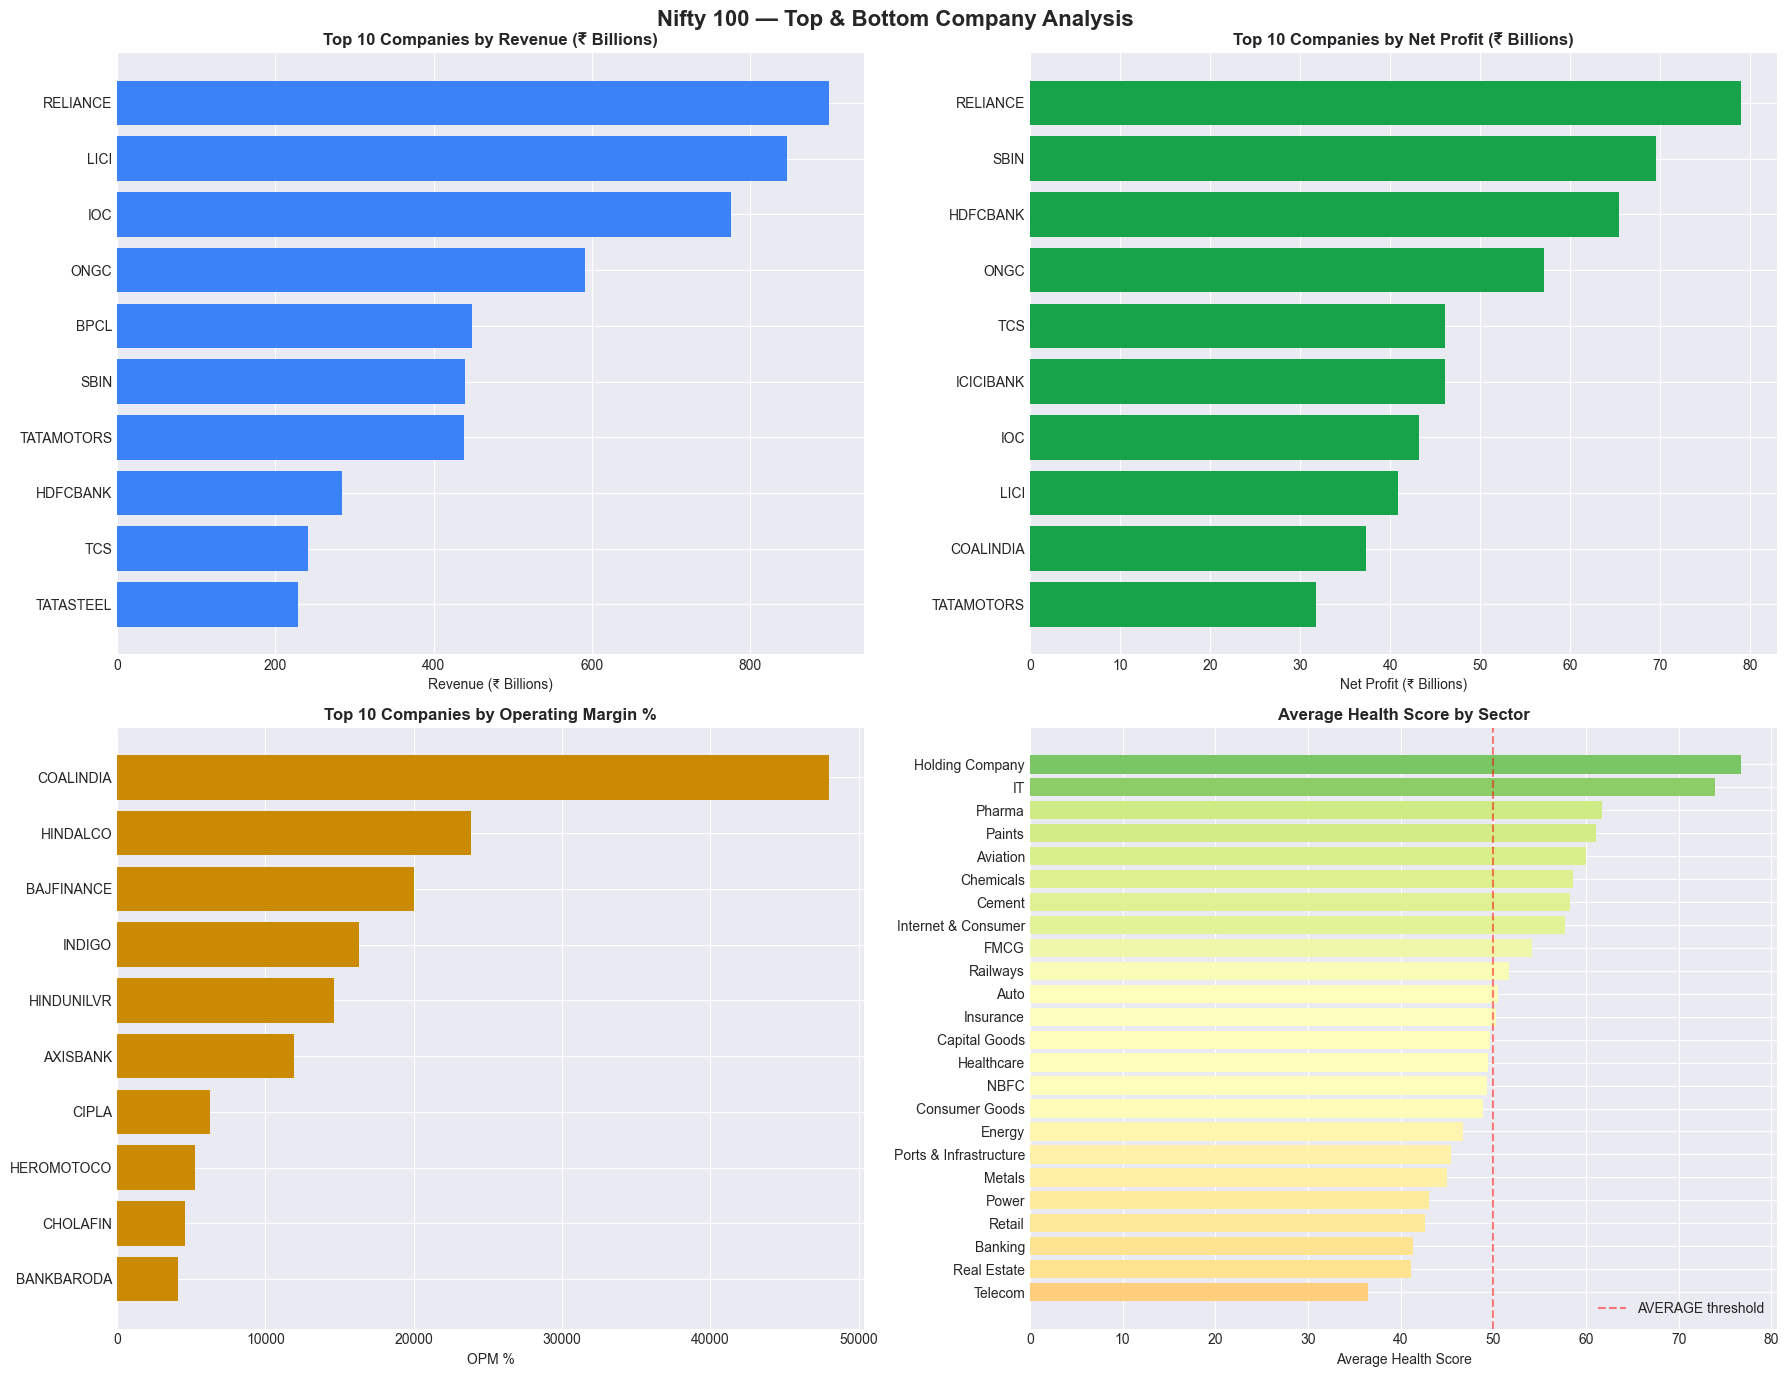

Chart saved!


In [2]:
# Cell 2 — Top 10 and Bottom 10 Companies by Key Metrics
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Nifty 100 — Top & Bottom Company Analysis", fontsize=16, fontweight='bold')

# Get latest year data per company
latest = df_pl.sort_values("sort_order").groupby("symbol").last().reset_index()

# ── Top 10 by Revenue ──
top10_rev = latest.nlargest(10, "sales")
bot10_rev = latest.nsmallest(10, "sales")

axes[0,0].barh(top10_rev["symbol"][::-1], top10_rev["sales"][::-1]/1000, color="#3b82f6")
axes[0,0].set_title("Top 10 Companies by Revenue (₹ Billions)", fontweight='bold')
axes[0,0].set_xlabel("Revenue (₹ Billions)")

# ── Top 10 by Net Profit ──
top10_profit = latest.nlargest(10, "net_profit")
axes[0,1].barh(top10_profit["symbol"][::-1], top10_profit["net_profit"][::-1]/1000, color="#16a34a")
axes[0,1].set_title("Top 10 Companies by Net Profit (₹ Billions)", fontweight='bold')
axes[0,1].set_xlabel("Net Profit (₹ Billions)")

# ── Top 10 by OPM% ──
top10_opm = latest[latest["opm_pct"] > 0].nlargest(10, "opm_pct")
axes[1,0].barh(top10_opm["symbol"][::-1], top10_opm["opm_pct"][::-1], color="#ca8a04")
axes[1,0].set_title("Top 10 Companies by Operating Margin %", fontweight='bold')
axes[1,0].set_xlabel("OPM %")

# ── Health Score Distribution by Sector ──
sector_scores = df_scores.groupby("sector_name")["overall_score"].mean().sort_values(ascending=False)
colors = plt.cm.RdYlGn([x/100 for x in sector_scores.values])
axes[1,1].barh(sector_scores.index[::-1], sector_scores.values[::-1], color=colors[::-1])
axes[1,1].set_title("Average Health Score by Sector", fontweight='bold')
axes[1,1].set_xlabel("Average Health Score")
axes[1,1].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='AVERAGE threshold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../data/clean/eda_top_bottom.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

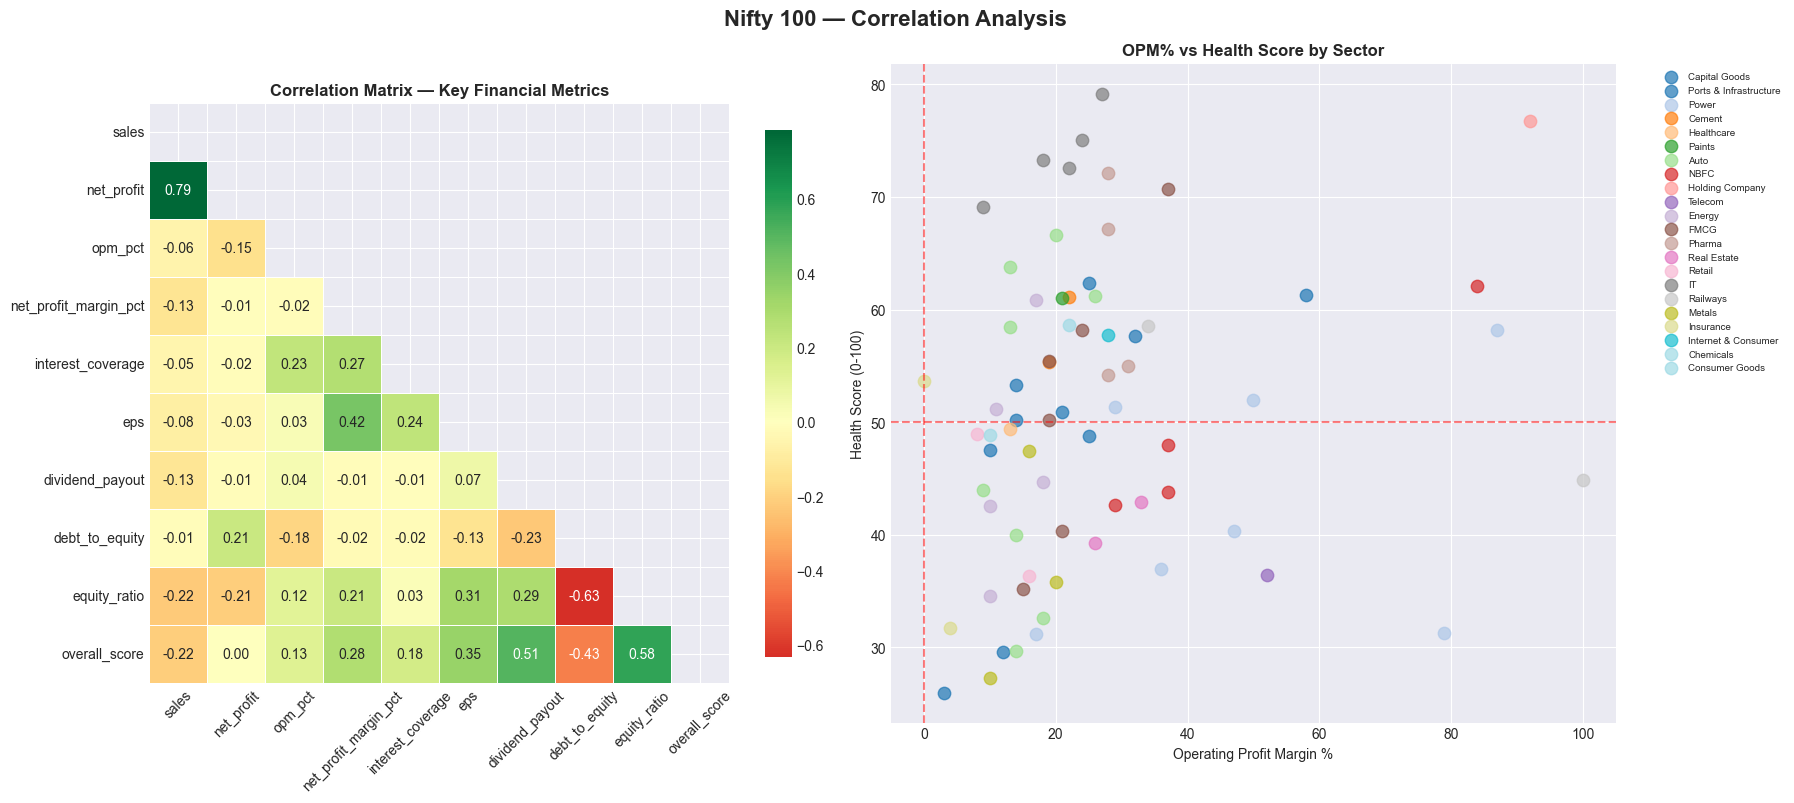

Chart saved!


In [3]:
# Cell 3 — Correlation Matrix
# Does ROE correlate with OPM%? Does D/E correlate with poor health scores?

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Nifty 100 — Correlation Analysis", fontsize=16, fontweight='bold')

# ── Merge P&L with scores for correlation ──
latest_pl = df_pl.sort_values("sort_order").groupby("symbol").last().reset_index()
latest_bs = df_bs.sort_values("fiscal_year").groupby("symbol").last().reset_index()

merged = latest_pl.merge(
    latest_bs[["symbol", "debt_to_equity", "equity_ratio"]],
    on="symbol", how="left"
).merge(
    df_scores[["symbol", "overall_score"]],
    on="symbol", how="left"
)

# Select numeric columns for correlation
corr_cols = [
    "sales", "net_profit", "opm_pct", "net_profit_margin_pct",
    "interest_coverage", "eps", "dividend_payout",
    "debt_to_equity", "equity_ratio", "overall_score"
]

corr_data = merged[corr_cols].apply(pd.to_numeric, errors='coerce')
corr_data = corr_data.replace([np.inf, -np.inf], np.nan)
corr_matrix = corr_data.corr()

# ── Heatmap ──
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes[0],
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Correlation Matrix — Key Financial Metrics", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# ── Scatter: OPM% vs Health Score ──
scatter_data = merged[["symbol", "opm_pct", "overall_score", "sector_name"]].dropna()
scatter_data = scatter_data[scatter_data["opm_pct"].between(-50, 100)]

sectors = scatter_data["sector_name"].unique()
colors  = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
sector_color_map = dict(zip(sectors, colors))

for sector in sectors:
    mask = scatter_data["sector_name"] == sector
    axes[1].scatter(
        scatter_data[mask]["opm_pct"],
        scatter_data[mask]["overall_score"],
        label=sector,
        alpha=0.7,
        s=80,
        color=sector_color_map[sector]
    )

axes[1].set_title("OPM% vs Health Score by Sector", fontweight='bold')
axes[1].set_xlabel("Operating Profit Margin %")
axes[1].set_ylabel("Health Score (0-100)")
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=0,  color='red', linestyle='--', alpha=0.5)
axes[1].legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../data/clean/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

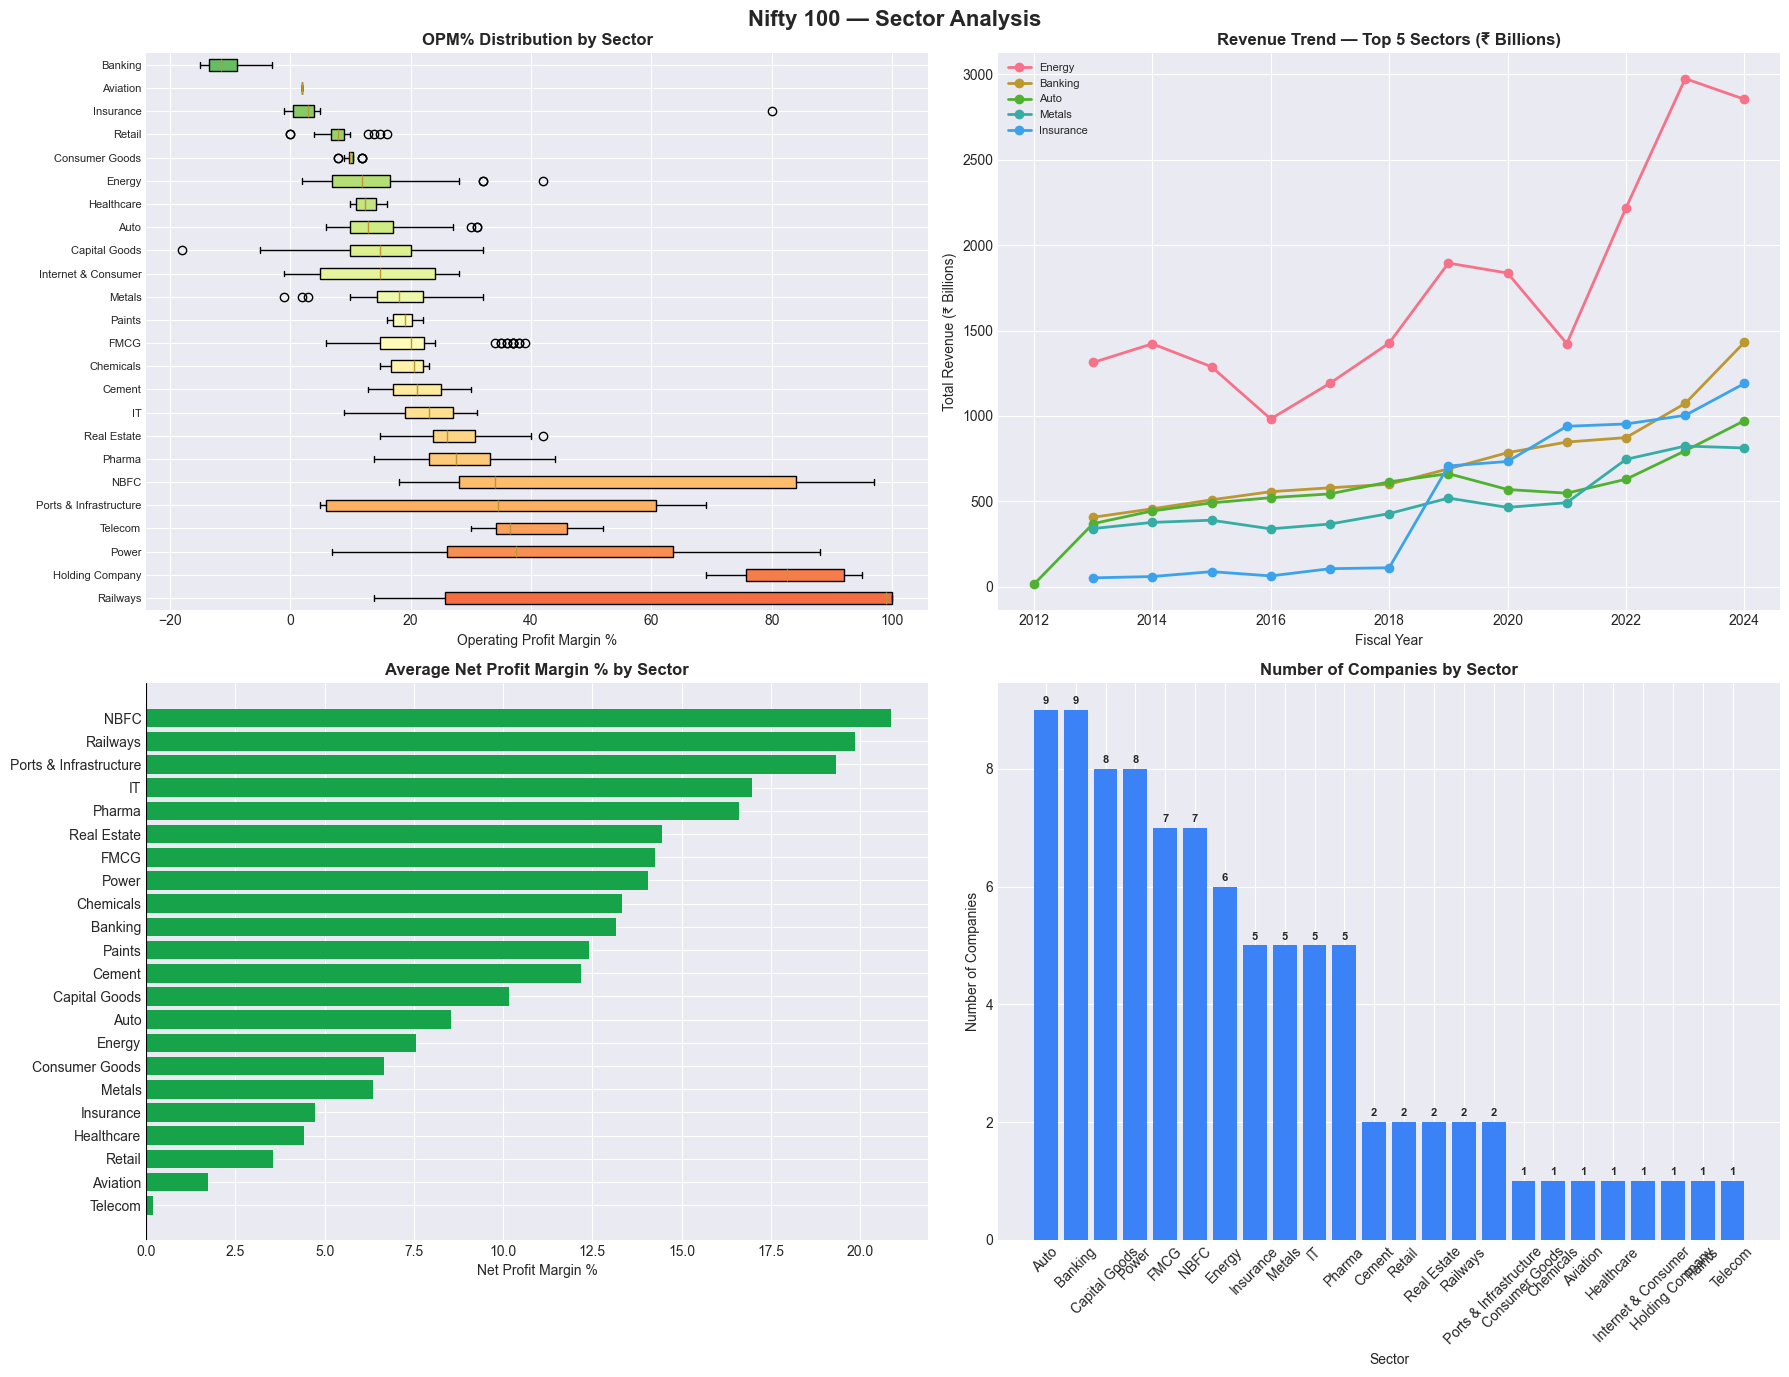

Chart saved!


In [4]:
# Cell 4 — Sector Box Plots and Revenue Trends
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Nifty 100 — Sector Analysis", fontsize=16, fontweight='bold')

# ── Box Plot: OPM% by Sector ──
sector_opm = df_pl[df_pl["opm_pct"].between(-20, 100)].copy()
sectors_ordered = sector_opm.groupby("sector_name")["opm_pct"].median().sort_values(ascending=False).index

sector_opm_pivot = [
    sector_opm[sector_opm["sector_name"] == s]["opm_pct"].dropna().values
    for s in sectors_ordered
]

bp = axes[0,0].boxplot(sector_opm_pivot, labels=sectors_ordered, patch_artist=True, vert=False)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sectors_ordered)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0,0].set_title("OPM% Distribution by Sector", fontweight='bold')
axes[0,0].set_xlabel("Operating Profit Margin %")
axes[0,0].tick_params(axis='y', labelsize=8)

# ── Revenue Trend by Top 5 Sectors ──
top5_sectors = df_pl.groupby("sector_name")["sales"].sum().nlargest(5).index.tolist()
sector_trend = df_pl[df_pl["sector_name"].isin(top5_sectors)].groupby(
    ["fiscal_year", "sector_name"])["sales"].sum().reset_index()

for sector in top5_sectors:
    data = sector_trend[sector_trend["sector_name"] == sector]
    axes[0,1].plot(data["fiscal_year"], data["sales"]/1000,
                   marker='o', label=sector, linewidth=2)

axes[0,1].set_title("Revenue Trend — Top 5 Sectors (₹ Billions)", fontweight='bold')
axes[0,1].set_xlabel("Fiscal Year")
axes[0,1].set_ylabel("Total Revenue (₹ Billions)")
axes[0,1].legend(fontsize=8)

# ── Net Profit Margin by Sector ──
sector_margin = df_pl.groupby("sector_name")["net_profit_margin_pct"].mean().sort_values()
sector_margin = sector_margin[sector_margin.between(-10, 50)]
colors = ["#dc2626" if x < 0 else "#16a34a" for x in sector_margin.values]
axes[1,0].barh(sector_margin.index, sector_margin.values, color=colors)
axes[1,0].set_title("Average Net Profit Margin % by Sector", fontweight='bold')
axes[1,0].set_xlabel("Net Profit Margin %")
axes[1,0].axvline(x=0, color='black', linewidth=0.8)

# ── Company Count by Sector ──
sector_count = df_pl["sector_name"].nunique()
company_sector = df_pl.groupby("sector_name")["symbol"].nunique().sort_values(ascending=False)
bars = axes[1,1].bar(company_sector.index, company_sector.values, color="#3b82f6")
axes[1,1].set_title("Number of Companies by Sector", fontweight='bold')
axes[1,1].set_xlabel("Sector")
axes[1,1].set_ylabel("Number of Companies")
axes[1,1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, company_sector.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                   str(val), ha='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.savefig('../data/clean/eda_sector_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [5]:
# Cell 5 — Key Insights Summary
print("=" * 60)
print("NIFTY 100 — EDA KEY INSIGHTS SUMMARY")
print("=" * 60)

# Insight 1 — Revenue concentration
latest = df_pl.sort_values("sort_order").groupby("symbol").last().reset_index()
top10_rev = latest.nlargest(10, "sales")
total_rev = latest["sales"].sum()
top10_share = top10_rev["sales"].sum() / total_rev * 100
print(f"\n📊 INSIGHT 1 — Revenue Concentration")
print(f"   Top 10 companies control {top10_share:.1f}% of total Nifty 100 revenue")
print(f"   Top company: {top10_rev.iloc[0]['symbol']} (₹{top10_rev.iloc[0]['sales']/1000:.0f}B)")

# Insight 2 — Profitability
profitable = (latest["net_profit"] > 0).sum()
print(f"\n📊 INSIGHT 2 — Profitability")
print(f"   {profitable} out of {len(latest)} companies are currently profitable")
print(f"   Average OPM%: {latest['opm_pct'].mean():.1f}%")
print(f"   Highest OPM%: {latest.nlargest(1,'opm_pct').iloc[0]['symbol']} ({latest['opm_pct'].max():.1f}%)")

# Insight 3 — Health scores
excellent = (df_scores["overall_score"] >= 85).sum()
good      = ((df_scores["overall_score"] >= 70) & (df_scores["overall_score"] < 85)).sum()
average   = ((df_scores["overall_score"] >= 50) & (df_scores["overall_score"] < 70)).sum()
weak      = ((df_scores["overall_score"] >= 35) & (df_scores["overall_score"] < 50)).sum()
poor      = (df_scores["overall_score"] < 35).sum()
print(f"\n📊 INSIGHT 3 — Health Score Distribution")
print(f"   EXCELLENT: {excellent} | GOOD: {good} | AVERAGE: {average} | WEAK: {weak} | POOR: {poor}")
print(f"   Average health score: {df_scores['overall_score'].mean():.1f}/100")

# Insight 4 — Best sector
best_sector = df_scores.groupby("sector_name")["overall_score"].mean().idxmax()
best_score  = df_scores.groupby("sector_name")["overall_score"].mean().max()
worst_sector= df_scores.groupby("sector_name")["overall_score"].mean().idxmin()
worst_score = df_scores.groupby("sector_name")["overall_score"].mean().min()
print(f"\n📊 INSIGHT 4 — Best and Worst Sectors")
print(f"   Best sector:  {best_sector} (avg score: {best_score:.1f})")
print(f"   Worst sector: {worst_sector} (avg score: {worst_score:.1f})")

# Insight 5 — Debt analysis
latest_bs = df_bs.sort_values("fiscal_year").groupby("symbol").last().reset_index()
debt_free = (latest_bs["debt_to_equity"] < 0.1).sum()
high_debt = (latest_bs["debt_to_equity"] > 2.0).sum()
print(f"\n📊 INSIGHT 5 — Debt Analysis")
print(f"   Debt-free companies (D/E < 0.1): {debt_free}")
print(f"   High debt companies (D/E > 2.0): {high_debt}")
print(f"   Average D/E ratio: {latest_bs['debt_to_equity'].mean():.2f}")

print("\n" + "=" * 60)
print("EDA COMPLETE — All charts saved to data/clean/")
print("=" * 60)

NIFTY 100 — EDA KEY INSIGHTS SUMMARY

📊 INSIGHT 1 — Revenue Concentration
   Top 10 companies control 51.7% of total Nifty 100 revenue
   Top company: RELIANCE (₹899B)

📊 INSIGHT 2 — Profitability
   90 out of 92 companies are currently profitable
   Average OPM%: 892.5%
   Highest OPM%: COALINDIA (47971.0%)

📊 INSIGHT 3 — Health Score Distribution
   EXCELLENT: 0 | GOOD: 7 | AVERAGE: 41 | WEAK: 29 | POOR: 11
   Average health score: 50.9/100

📊 INSIGHT 4 — Best and Worst Sectors
   Best sector:  Holding Company (avg score: 76.8)
   Worst sector: Telecom (avg score: 36.5)

📊 INSIGHT 5 — Debt Analysis
   Debt-free companies (D/E < 0.1): 33
   High debt companies (D/E > 2.0): 18
   Average D/E ratio: 1.65

EDA COMPLETE — All charts saved to data/clean/
